# 3.7. Weight Decay

Our machine learning models might fit on training data well but fail to generalize. A simile would be a student who can perfect memorize the answers to past exam questions but not learn any of the course material. While such a student would score perfectly on an exam with only recycled exam questions, they would fail miserably on an exam consisting of only new questions, even though the new questions may be based on the same course content.

In machine learning, this typically happens when 1 or more of the following occur:

1. The amount of training data is limited relative to the problem domain
1. The model is too complex but the patterns in the underlying problem domain is simple
1. The model is trained on the training data over an excessive number of epochs
1. The validation set is reused excessively to refine our hyperparameters. This causes us to achieve a low training and validation error but the model may fail miserably on true, unseen data

One commonly used method to mitigate overfitting is by the introducution of weight decay. Basically, given a weight vector $\mathbf{w}$, we not only want to minimize the MSE loss but also keep the squared $\ell_{2}$ norm of our weight vector $\lVert\mathbf{w}\rVert^{2}$ within a certain threshold. We can do this by introducing a penalty term $\frac{\lambda}{2}\lVert\mathbf{w}\rVert^{2}$ to our loss function where $\lambda$ is a tunable hyperparameter.

In the following sections, we shall see how our linear regression model overfits on high-dimensional data with limited samples, and how to mitigate it with weight decay.

## 3.7.2. High-Dimensional Linear Regression

Let's generate some high-dimensional synthetic data with the following characteristics using scikit-learn.

1. 200 input features
1. 20 training samples
1. 100 validation samples
1. Bias $b = 0.05$
1. Noise $\epsilon \sim \mathcal{N}(0,0.01^2)$

Remember that the weight vector $\mathbf{w}$ of the underlying ground truth linear function is automatically determined by `make_regression`. We can set `coef=True` to obtain the underlying weight vector which should not be necessary here.

In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=120,
                       n_features=200,
                       n_informative=200,
                       n_targets=1,
                       bias=0.05,
                       noise=0.01)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100)
y_train, y_test = y_train.reshape(-1, 1), y_test.reshape(-1, 1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20, 200), (100, 200), (20, 1), (100, 1))

Recall we also need to standardize the training labels with `StandardScaler` to stabilize our minibatch SGD.

In [2]:
from sklearn.preprocessing import StandardScaler

print(f'Before scaling: mean = {y_train.mean():.4f}, stddev = {y_train.std():.4f}')
scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train)
print(f'After scaling: mean = {y_train_scaled.mean():.4f}, stddev = {y_train_scaled.std():.4f}')

Before scaling: mean = 40.8622, stddev = 634.6069
After scaling: mean = -0.0000, stddev = 1.0000


Let's define our neural network with a single fully connected layer. The fully connected layer has 200 input channels and 1 output channel. Specify the learning rate as `lr` and weight decay as `wd`. By default, we have `lr=0.01` and `wd=0.0`.

In [3]:
import mindspore
mindspore.set_device(device_target='Ascend', device_id=0)

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2


In [4]:
import mindspore.nn as nn
from mindspore import dtype as mstype

class MyModel(nn.Cell):
    def __init__(self, lr=0.01, wd=0.0):
        super().__init__()
        self.lr = lr
        self.wd = wd
        self.dense1 = nn.Dense(200, 1, dtype=mstype.float16)

    def construct(self, x):
        y_hat = self.dense1(x)
        return y_hat

model1 = MyModel()
model1

MyModel(
  (dense1): Dense(input_channels=200, output_channels=1, has_bias=True)
)

Define the loss function and optimizer.

In [5]:
loss_fn = nn.MSELoss()
optimizer1 = nn.SGD(model1.trainable_params(), learning_rate=model1.lr, weight_decay=model1.wd)

Now define our forward and gradient functions.

In [6]:
def forward_fn1(X, y):
    y_hat = model1(X)
    loss = loss_fn(y_hat, y)
    return loss, y_hat

grad_fn1 = mindspore.value_and_grad(fn=forward_fn1,
                                    grad_position=None,
                                    weights=optimizer1.parameters,
                                    has_aux=True)

Define our training step and training functions.

In [7]:
def train_step1(X, y):
    (loss, _), grads = grad_fn1(X, y)
    optimizer1(grads)
    return loss

def train1(dataset, epoch=0):
    training_losses_by_batch_scaled = []
    print(f'Epoch {epoch} start')
    size = dataset.get_dataset_size()
    model1.set_train()
    for batch_idx, (X_batch, y_batch) in enumerate(dataset.create_tuple_iterator()):
        loss = train_step1(X_batch, y_batch)
        print(f'Training loss (scaled): {loss.asnumpy():.4f} [{batch_idx}/{size}]')
        training_losses_by_batch_scaled.append(ops.cast(loss, dtype=mstype.float64))
    print(f'Epoch {epoch} end')
    return training_losses_by_batch_scaled

Define our validation function.

In [8]:
def validate1():
    model1.set_train(False)
    y_hat_scaled = model1(mindspore.Tensor(X_test.astype(np.float16))).asnumpy()
    y_test_scaled = scaler.transform(y_test)
    validation_loss_scaled = loss_fn(mindspore.Tensor(y_hat_scaled), mindspore.Tensor(y_test_scaled))
    y_hat = scaler.inverse_transform(y_hat_scaled)
    validation_loss = loss_fn(mindspore.Tensor(y_hat), mindspore.Tensor(y_test))
    print(f'Validation loss (scaled): {validation_loss_scaled.asnumpy():.4f}')
    print(f'Validation loss: {validation_loss.asnumpy():.4f}')
    return validation_loss_scaled

Now train our model on the 20 training samples over 10 epochs. We'll also compute the validation loss at the end of each epoch to demonstrate overfitting.

In [9]:
import numpy as np
import mindspore.dataset as ds
import mindspore.ops as ops

train_ds = ds.NumpySlicesDataset(data=(X_train.astype(np.float16), y_train_scaled.astype(np.float16)), column_names=['features', 'labels'])
train_ds = train_ds.batch(4)
training_losses = []
validation_losses = []
for i in range(10):
    training_losses.extend(train1(train_ds, epoch=i))
    validation_losses.append(validate1())
training_losses = ops.stack(training_losses, axis=0)
validation_losses = ops.stack(validation_losses, axis=0)
training_losses, validation_losses

Epoch 0 start


/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

.Training loss (scaled): 1.3564 [0/5]
Training loss (scaled): 1.6582 [1/5]
Training loss (scaled): 0.5767 [2/5]
Training loss (scaled): 0.7646 [3/5]
Training loss (scaled): 1.2822 [4/5]
Epoch 0 end
Validation loss (scaled): 2.0862
Validation loss: 840134.3750
Epoch 1 start
Training loss (scaled): 0.0440 [0/5]
Training loss (scaled): 0.0203 [1/5]
Training loss (scaled): 0.0215 [2/5]
Training loss (scaled): 0.0133 [3/5]
Training loss (scaled): 0.0580 [4/5]
Epoch 1 end
Validation loss (scaled): 2.0660
Validation loss: 831991.2500
Epoch 2 start
Training loss (scaled): 0.0025 [0/5]
Training loss (scaled): 0.0008 [1/5]
Training loss (scaled): 0.0037 [2/5]
Training loss (scaled): 0.0012 [3/5]
Training loss (scaled): 0.0008 [4/5]
Epoch 2 end
Validation loss (scaled): 2.0610
Validation loss: 830008.7500
Epoch 3 start
Training loss (scaled): 0.0000 [0/5]
Training loss (scaled): 0.0001 [1/5]
Training loss (scaled): 0.0001 [2/5]
Training loss (scaled): 0.0000 [3/5]
Training loss (scaled): 0.0000 [

(Tensor(shape=[50], dtype=Float64, value= [ 1.35644531e+00,  1.65820312e+00,  5.76660156e-01,  7.64648438e-01,  1.28222656e+00,  4.40368652e-02,  2.03247070e-02,  2.15148926e-02,  1.32522583e-02,  5.80444336e-02,  2.53486633e-03,  8.11100006e-04, 
   3.73840332e-03,  1.22547150e-03,  8.32557678e-04,  2.51531601e-05,  1.01923943e-04,  1.00374222e-04,  2.11596489e-05,  2.00271606e-05,  6.02006912e-06,  1.54972076e-06,  1.25169754e-06,  6.19888306e-06, 
   1.12652779e-05,  4.76837158e-07,  5.36441803e-07,  5.36441803e-07,  3.57627869e-07,  8.34465027e-07,  5.96046448e-07,  1.19209290e-07,  0.00000000e+00,  0.00000000e+00,  2.98023224e-07,  0.00000000e+00, 
   0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 
   0.00000000e+00,  0.00000000e+00]),
 Tensor(shape=[10], dtype=Float64, value= [ 2.08617973e+00,  2.06600952e+00,  2.06104898e+00,

Notice the training loss decreases to effectively zero at around 5 epochs, but the validation loss remains high and steady. Let's plot the training vs. validation losses with Matplotlib to better visualize the problem.

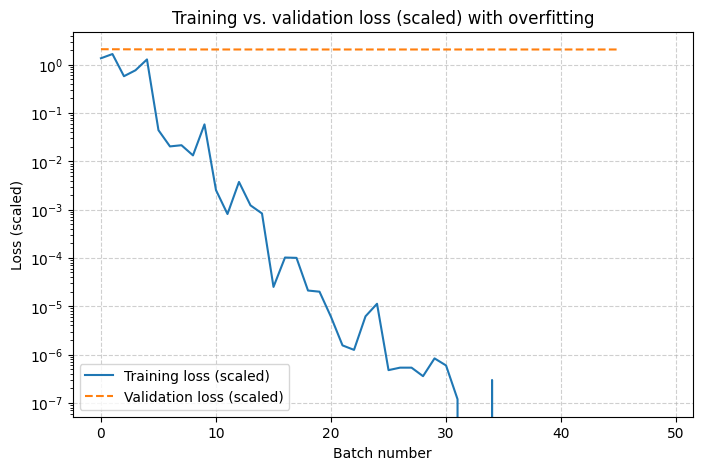

In [10]:
import matplotlib.pyplot as plt

batch_x = np.arange(50)
epoch_x = np.arange(10) * 5
training_losses_y = training_losses.asnumpy()
validation_losses_y = validation_losses.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(batch_x, training_losses_y, label='Training loss (scaled)', linestyle='-')
plt.plot(epoch_x, validation_losses_y, label='Validation loss (scaled)', linestyle='--')

plt.title('Training vs. validation loss (scaled) with overfitting')
plt.xlabel('Batch number')
plt.ylabel('Loss (scaled)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

## 3.7.4. Concise Implementation

Now let's try the same with the weight decay factor $\lambda = 3$. The training loss does not decrease as sharply but the resulting model generalizes better on unseen data.

In [11]:
model2 = MyModel(wd=3)
model2

MyModel(
  (dense1): Dense(input_channels=200, output_channels=1, has_bias=True)
)

In [12]:
loss_fn

MSELoss()

In [13]:
optimizer2 = nn.SGD(model2.trainable_params(), learning_rate=model2.lr, weight_decay=model2.wd)
optimizer2

SGD()

In [14]:
def forward_fn2(X, y):
    y_hat = model2(X)
    loss = loss_fn(y_hat, y)
    return loss, y_hat

grad_fn2 = mindspore.value_and_grad(fn=forward_fn2,
                                    grad_position=None,
                                    weights=optimizer2.parameters,
                                    has_aux=True)

In [15]:
def train_step2(X, y):
    (loss, _), grads = grad_fn2(X, y)
    optimizer2(grads)
    return loss

def train2(dataset, epoch=0):
    print(f'Epoch {epoch} start')
    training_losses_by_batch_scaled = []
    size = dataset.get_dataset_size()
    model2.set_train()
    for batch_idx, (X_batch, y_batch) in enumerate(dataset.create_tuple_iterator()):
        loss = train_step2(X_batch, y_batch)
        print(f'Training loss (scaled): {loss.asnumpy():.4f} [{batch_idx}/{size}]')
        training_losses_by_batch_scaled.append(ops.cast(loss, dtype=mstype.float64))
    print(f'Epoch {epoch} end')
    return training_losses_by_batch_scaled

def validate2():
    model2.set_train(False)
    y_hat_scaled = model2(mindspore.Tensor(X_test.astype(np.float16))).asnumpy()
    y_hat = scaler.inverse_transform(y_hat_scaled)
    y_test_scaled = scaler.transform(y_test)
    validation_loss_scaled = loss_fn(mindspore.Tensor(y_hat_scaled), mindspore.Tensor(y_test_scaled))
    validation_loss = loss_fn(mindspore.Tensor(y_hat), mindspore.Tensor(y_test))
    print(f'Validation loss (scaled): {validation_loss_scaled.asnumpy():.4f}')
    print(f'Validation loss: {validation_loss.asnumpy():.4f}')
    return validation_loss_scaled

In [16]:
train_ds = ds.NumpySlicesDataset(data=(X_train.astype(np.float16), y_train_scaled.astype(np.float16)), column_names=['features', 'labels'])
train_ds = train_ds.batch(4)
training_losses_scaled = []
validation_losses_scaled = []

for i in range(6):
    training_losses_scaled.extend(train2(train_ds, epoch=i))
    validation_losses_scaled.append(validate2())

training_losses_scaled = ops.stack(training_losses_scaled, axis=0)
validation_losses_scaled = ops.stack(validation_losses_scaled, axis=0)
training_losses_scaled, validation_losses_scaled

Epoch 0 start
.

/usr/local/Ascend/cann-8.5.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:97: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)
/usr/local/Ascend/cann-8.5.0/opp/built-in/op_impl/ai_core/tbe/impl/ops_legacy/dynamic/gelu_grad_v2.py:157: SyntaxWarning: invalid escape sequence '\h'
  gelu_grad_erf = erfc(-\hat{x}) / 2 + (1 /sqrt(Pi)) * (\hat{x}) * exp(-\hat{x}^2)


..Training loss (scaled): 2.7500 [0/5]
Training loss (scaled): 0.3047 [1/5]
Training loss (scaled): 1.0557 [2/5]
Training loss (scaled): 1.0693 [3/5]
Training loss (scaled): 1.5361 [4/5]
Epoch 0 end
Validation loss (scaled): 1.8666
Validation loss: 751733.8750
Epoch 1 start
Training loss (scaled): 0.0088 [0/5]
Training loss (scaled): 0.0674 [1/5]
Training loss (scaled): 0.0452 [2/5]
Training loss (scaled): 0.2323 [3/5]
Training loss (scaled): 0.1077 [4/5]
Epoch 1 end
Validation loss (scaled): 1.8046
Validation loss: 726760.7500
Epoch 2 start
Training loss (scaled): 0.0226 [0/5]
Training loss (scaled): 0.0065 [1/5]
Training loss (scaled): 0.0201 [2/5]
Training loss (scaled): 0.0665 [3/5]
Training loss (scaled): 0.0305 [4/5]
Epoch 2 end
Validation loss (scaled): 1.7549
Validation loss: 706741.6250
Epoch 3 start
Training loss (scaled): 0.0023 [0/5]
Training loss (scaled): 0.0211 [1/5]
Training loss (scaled): 0.0695 [2/5]
Training loss (scaled): 0.0405 [3/5]
Training loss (scaled): 0.0573 

(Tensor(shape=[30], dtype=Float64, value= [ 2.75000000e+00,  3.04687500e-01,  1.05566406e+00,  1.06933594e+00,  1.53613281e+00,  8.79669189e-03,  6.73828125e-02,  4.51965332e-02,  2.32299805e-01,  1.07666016e-01,  2.26135254e-02,  6.50405884e-03, 
   2.00653076e-02,  6.65283203e-02,  3.04565430e-02,  2.30026245e-03,  2.11334229e-02,  6.95190430e-02,  4.04968262e-02,  5.72509766e-02,  9.47570801e-03,  7.50350952e-03,  2.65197754e-02,  3.91540527e-02, 
   5.03540039e-02,  3.88717651e-03,  3.66516113e-02,  7.06481934e-03,  9.13696289e-02,  3.50341797e-02]),
 Tensor(shape=[6], dtype=Float64, value= [ 1.86661029e+00,  1.80461967e+00,  1.75490928e+00,  1.72624469e+00,  1.69446325e+00,  1.67550361e+00]))

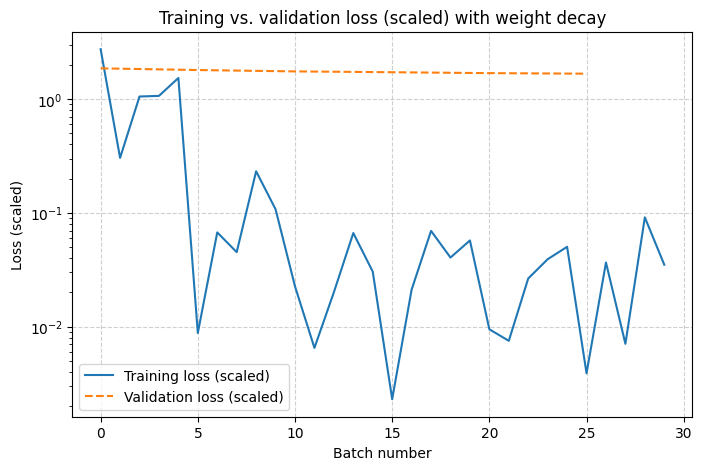

In [17]:
plt.figure(figsize=(8, 5))

batch_x = np.arange(30)
epoch_x = np.arange(6) * 5
training_losses_y = training_losses_scaled.asnumpy()
validation_losses_y = validation_losses_scaled.asnumpy()

plt.plot(batch_x, training_losses_y, label='Training loss (scaled)', linestyle='-')
plt.plot(epoch_x, validation_losses_y, label='Validation loss (scaled)', linestyle='--')

plt.title('Training vs. validation loss (scaled) with weight decay')
plt.xlabel('Batch number')
plt.ylabel('Loss (scaled)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

Not too much of an improvement, but the decrease in validation loss is observable. Notice the gentle downward slope of the validation loss curve - at least it's no longer effectively horizontal!

## 3.7.5. Summary

We saw in this chapter our first and most common technique in improving the ability of our model to generalize on unseen inputs through weight decay. Weight decay works well with MSE loss and minibatch SGD, and the general principle of constraining the learned weights to prevent overfitting applies to other machine learning algorithms as well.